# Schritt 1 vs. Baseline - Auswertung (Frühjahr 7.5cm Finetune)

Eigenständige Ergebnis-Dokumentation für **Schedule-Schritt 1**
(`configs/finetune_step1_spring75.yaml`): un-finetuntes `freudenberg2022`-Baseline-Modell
vs. der auf **100% Frühjahr 7.5cm, RGBI+NDVI** finegetunte Run `step1_spring75`.

**Fairer Vergleich:** beide Auswertungen nutzen dasselbe kronenweise IoU-Matching
(Schwelle 0.5) und **dasselbe Postprocessing (Default `min_dist=10, sigma=1`)** - nur so
sind die Zahlen apples-to-apples. Datenquellen (alle als `nda` erzeugt):

| Quelle | Datei |
|---|---|
| Baseline (PP 10/1) | `3_Model/runs/baseline_eval.csv` - `2_BaselineModel/baseline_eval.py` |
| Baseline (PP 30/2, optional) | `3_Model/runs/baseline_eval_pp30.csv` |
| step1 Test-Eval (PP 10/1) | `3_Model/runs/step1_spring75/eval_test.csv` - `3_Model/src/evaluate.py` |
| step1 Trainingsverlauf | `3_Model/runs/step1_spring75/train_log.csv` |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path('/home/leafline/leafline')
RUNS_DIR = REPO / '3_Model' / 'runs'

COLORS = {'baseline': '#eda100', 'step1_spring75': '#2a78d6'}

def load(p, tag=None):
    p = Path(p)
    if not p.exists():
        print(f'FEHLT: {p}'); return None
    df = pd.read_csv(p)
    if tag: df['run'] = tag
    print(f'geladen: {p.name}  ({len(df)} Zeilen)')
    return df

baseline_df = load(RUNS_DIR / 'baseline_eval.csv', 'baseline')
step1_df    = load(RUNS_DIR / 'step1_spring75' / 'eval_test.csv', 'step1_spring75')
train_log   = load(RUNS_DIR / 'step1_spring75' / 'train_log.csv')
# optional: getuntes Postprocessing der Baseline
baseline_pp30 = load(RUNS_DIR / 'baseline_eval_pp30.csv', 'baseline_pp30')

geladen: baseline_eval.csv  (6 Zeilen)
geladen: eval_test.csv  (2 Zeilen)
geladen: train_log.csv  (24 Zeilen)
geladen: baseline_eval_pp30.csv  (6 Zeilen)


## 1. Trainingsverlauf - pixelweise Val-F1 (`step1_spring75`)

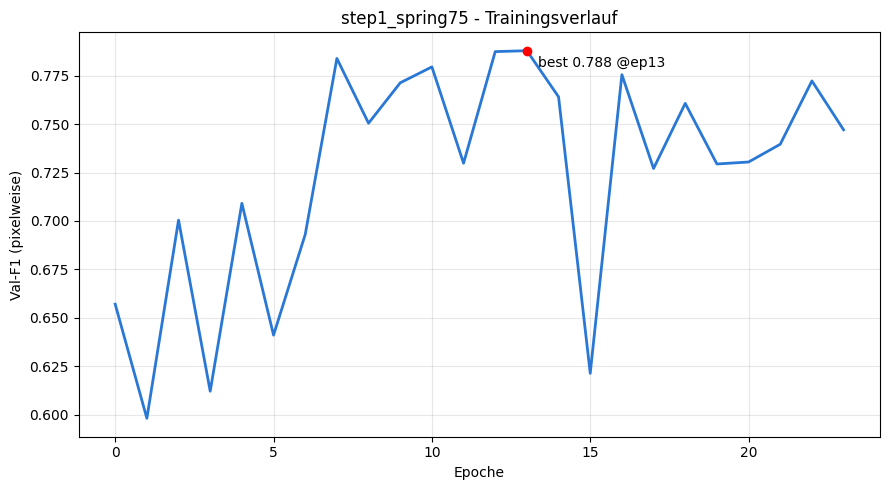

Bestes pixelweises Val-F1: 0.7879 @ Epoche 13  (v1-Referenz: 0.706 @ep35)


In [2]:
if train_log is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_log['epoch'], train_log['val_f1'], color=COLORS['step1_spring75'], lw=2)
    bi = train_log['val_f1'].idxmax()
    be, bf = int(train_log.loc[bi,'epoch']), train_log.loc[bi,'val_f1']
    ax.scatter([be],[bf], color='red', zorder=5)
    ax.annotate(f'best {bf:.3f} @ep{be}', (be,bf), textcoords='offset points', xytext=(8,-12))
    ax.set_xlabel('Epoche'); ax.set_ylabel('Val-F1 (pixelweise)')
    ax.set_title('step1_spring75 - Trainingsverlauf'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'Bestes pixelweises Val-F1: {bf:.4f} @ Epoche {be}  (v1-Referenz: 0.706 @ep35)')

## 2. Kronenweise Test-F1: Baseline vs. step1 (identisches PP 10/1)

Mikro-Schnitt (TP/FP/FN erst über beide Testgebiete summiert, dann Metrik):

| Auflösung | Baseline F1 | step1 F1 | Δ |
|---|---|---|---|
| **7.5cm** (Frühjahr, nativ) | **0.000** | **0.120** | **+0.120** |
| **20cm** (Sommer) | **0.339** | 0.052 | **−0.287** |
| **20cm-spring** (Frühjahr) | 0.044 | 0.041 | ≈ 0 |

Die Tabelle unten wird live aus den CSVs neu berechnet.

In [3]:
def micro_f1(g):
    tp, fp, fn = g['tp'].sum(), g['fp'].sum(), g['fn'].sum()
    p = tp/(tp+fp) if tp+fp else 0.0
    r = tp/(tp+fn) if tp+fn else 0.0
    f = 2*p*r/(p+r) if p+r else 0.0
    return pd.Series({'precision':p,'recall':r,'f1':f,'tp':tp,'fp':fp,'fn':fn})

frames = [d for d in (baseline_df, step1_df) if d is not None]
eval_df = pd.concat(frames, ignore_index=True)
micro = eval_df.groupby(['run','aufloesung']).apply(micro_f1).reset_index()

pivot = micro.pivot(index='run', columns='aufloesung', values='f1')
order = [c for c in ['7.5cm','20cm','20cm-spring'] if c in pivot.columns]
print('Mikro-F1 je Run × Auflösung:')
print(pivot[order].round(4))

Mikro-F1 je Run × Auflösung:
aufloesung       7.5cm    20cm  20cm-spring
run                                        
baseline        0.0000  0.3397       0.0442
step1_spring75  0.2082     NaN          NaN


/tmp/ipykernel_18643/1998631191.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  micro = eval_df.groupby(['run','aufloesung']).apply(micro_f1).reset_index()


## 3. Vergleichsdiagramm - F1 je Auflösung

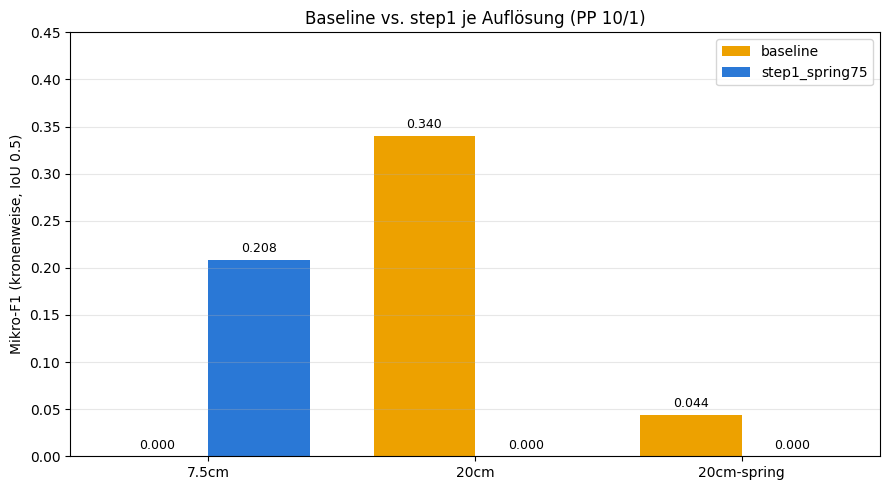

In [4]:
res_order = [r for r in ['7.5cm','20cm','20cm-spring'] if r in micro['aufloesung'].unique()]
runs = ['baseline','step1_spring75']
x = np.arange(len(res_order)); w = 0.38
fig, ax = plt.subplots(figsize=(9,5))
for k,run in enumerate(runs):
    vals = [micro[(micro.run==run)&(micro.aufloesung==r)]['f1'].values[0]
            if not micro[(micro.run==run)&(micro.aufloesung==r)].empty else 0 for r in res_order]
    ax.bar(x + (k-0.5)*w, vals, width=w, label=run, color=COLORS.get(run,'#ccc'))
    for xi,v in zip(x + (k-0.5)*w, vals):
        ax.text(xi, v+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(res_order)
ax.set_ylabel('Mikro-F1 (kronenweise, IoU 0.5)'); ax.set_ylim(0, max(0.45, pivot[order].values.max()*1.2))
ax.set_title('Baseline vs. step1 je Auflösung (PP 10/1)'); ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 4. Befunde & Schedule-Entscheidung

**1. Bei 7.5cm ist der Finetune ein klarer, notwendiger Gewinn.**
Die Baseline erkennt bei nativer 7.5cm-Auflösung praktisch nichts (16 bzw. 1 Vorhersage
bei 357/375 GT, **0 Treffer, F1=0**) - `freudenberg2022` ist auf ~20cm trainiert und bei
7.5cm out-of-distribution. step1 hebt das auf **F1=0.120**. Das ist genau das im Schedule
erwartete Ergebnis („especially spring 7.5cm gets better").

**2. Bei 20cm bricht step1 dramatisch ein - dort ist die Baseline am stärksten.**
0.339 → 0.052. Der reine 7.5cm-Frühjahr-Finetune spezialisiert das Modell auf 7.5cm und
verliert 20cm (nie 20cm-Daten gesehen). Das ist der **Auslöser für Schedule-Schritt 2**
(„if 20cm notably worse → separate Modelle je Auflösung").

**3. 20cm-spring ist der harte Fall - beide scheitern** (0.044 vs 0.041): niedrige
Auflösung *und* Frühjahrs-Laubzustand; die Baseline liefert bei HoernNord 0 Vorhersagen.

**Postprocessing-Hinweis.** Das „getunte" `min_dist=30/sigma=2` (aus `debug_predictions.ipynb`,
dort fürs *Finetune*-Modell bei 7.5cm) generalisiert **nicht**: für die Baseline bei 20cm
ist Default 10/1 (0.339) besser als 30/2 (0.263), bei 7.5cm zerstört 30/2 alles. →
Postprocessing muss pro Modell×Auflösung getunt werden. step1 über-segmentiert bei 7.5cm
noch (408 vs. 357 GT) - mit per-Auflösung getuntem PP läge step1s 7.5cm-F1 höher.

**Fazit:** Schritt 1 ist inhaltlich erfolgreich (0 → 0.120 bei 7.5cm), belegt aber zugleich,
dass ein Modell nicht alle Auflösungen bedient. → weiter zu **Schritt 2** (100% Frühjahr 20cm).
